In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [33]:


# Reproducibility
np.random.seed(42)

# Number of synthetic heats
n = 1500

# Generate input variables
scrap_quality_idx = np.random.uniform(0.70, 1.00, n)
hot_heel_frac = np.random.uniform(0.10, 0.45, n)
oxygen_flow_nm3_t = np.random.uniform(20, 50, n)
carbon_injection_kg_t = np.random.uniform(5, 20, n)
power_setting_idx = np.random.uniform(0.75, 1.05, n)

# Building target using engineering-guided relationships

# Base electrical energy demand
base_energy = 455

# Effects
scrap_effect = 85 * (scrap_quality_idx - 0.70) / 0.30
hot_heel_effect = 70 * (hot_heel_frac - 0.10) / 0.35

#Penalties
oxygen_penalty = 0.10 * (oxygen_flow_nm3_t - 32)**2
carbon_penalty = 0.35 * (carbon_injection_kg_t - 11)**2
power_penalty = 25 * (power_setting_idx - 0.90)**2

# Random process noise
noise = np.random.normal(0, 6, n)

# Final specific energy consumption
specific_energy_kwh_t = (
    base_energy
    - scrap_effect
    - hot_heel_effect
    + oxygen_penalty
    + carbon_penalty
    + power_penalty
    + noise
)

# Clamping to realistic bounds
specific_energy_kwh_t = np.clip(specific_energy_kwh_t, 330, 470)

# Creating DataFrame
df = pd.DataFrame({
    "scrap_quality_idx": np.round(scrap_quality_idx, 3),
    "hot_heel_frac": np.round(hot_heel_frac, 3),
    "oxygen_flow_nm3_t": np.round(oxygen_flow_nm3_t, 2),
    "carbon_injection_kg_t": np.round(carbon_injection_kg_t, 2),
    "power_setting_idx": np.round(power_setting_idx, 2),
    "specific_energy_kwh_t": np.round(specific_energy_kwh_t, 2)
})

# Save to CSV
df.to_csv("synthetic_eaf_energy_data.csv", index=False)



In [34]:

df = pd.read_csv("synthetic_eaf_energy_data.csv")
df

,scrap_quality_idx,hot_heel_frac,oxygen_flow_nm3_t,carbon_injection_kg_t,power_setting_idx,specific_energy_kwh_t
0,0.812,0.282,40.18,13.99,0.94,404.21
1,0.985,0.268,43.90,12.71,0.80,357.04
2,0.920,0.109,27.51,9.32,1.01,398.16
3,0.880,0.219,38.75,5.10,0.93,397.49
4,0.747,0.233,37.15,12.44,0.80,408.26
...,...,...,...,...,...,...
1495,0.900,0.403,38.30,15.27,0.77,337.80
1496,0.886,0.155,34.65,12.55,0.77,397.98
1497,0.839,0.208,24.00,16.48,1.01,405.63
1498,0.814,0.202,27.84,12.28,0.81,404.78


In [35]:
df.columns

Index(['scrap_quality_idx', 'hot_heel_frac', 'oxygen_flow_nm3_t',
       'carbon_injection_kg_t', 'power_setting_idx', 'specific_energy_kwh_t'],
      dtype='object')

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   scrap_quality_idx      1500 non-null   float64
 1   hot_heel_frac          1500 non-null   float64
 2   oxygen_flow_nm3_t      1500 non-null   float64
 3   carbon_injection_kg_t  1500 non-null   float64
 4   power_setting_idx      1500 non-null   float64
 5   specific_energy_kwh_t  1500 non-null   float64
dtypes: float64(6)
memory usage: 70.4 KB


In [37]:
df.shape

(1500, 6)

In [38]:
df.describe()

,scrap_quality_idx,hot_heel_frac,oxygen_flow_nm3_t,carbon_injection_kg_t,power_setting_idx,specific_energy_kwh_t
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,0.849807,0.275150,34.680853,12.488927,0.897127,393.352567
std,0.088206,0.101272,8.555295,4.344987,0.085893,34.018946
min,0.701000,0.100000,20.000000,5.000000,0.750000,330.000000
25%,0.771000,0.190000,27.247500,8.727500,0.820000,368.580000
50%,0.852000,0.277000,34.630000,12.345000,0.900000,393.235000
75%,0.926000,0.364000,41.880000,16.272500,0.970000,417.972500
max,1.000000,0.449000,49.990000,19.990000,1.050000,470.000000


In [39]:
df.duplicated().sum()

0

In [40]:
df.skew()

scrap_quality_idx       -0.007995
hot_heel_frac           -0.021718
oxygen_flow_nm3_t        0.028524
carbon_injection_kg_t    0.033383
power_setting_idx        0.069829
specific_energy_kwh_t    0.060161
dtype: float64

In [41]:
# Features and target
X = df[[
    "scrap_quality_idx",
    "hot_heel_frac",
    "oxygen_flow_nm3_t",
    "carbon_injection_kg_t",
    "power_setting_idx"
]]

y = df["specific_energy_kwh_t"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [42]:
#Linear  Regression

# Train
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Prediction
y_pred_lr = lr_model.predict(X_test)



In [43]:
# Evaluation
rmse_lr = mean_squared_error(y_test, y_pred_lr) ** 0.5
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print("RMSE:", round(rmse_lr, 2))
print("R²:", round(r2_lr, 3))

Linear Regression Results
RMSE: 11.38
R²: 0.899


In [44]:
#RandomForest

# Train
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

rf_model.fit(X_train, y_train)

# Prediction
y_pred_rf = rf_model.predict(X_test)



In [45]:
# Evaluation
rmse_rf = mean_squared_error(y_test, y_pred_rf) ** 0.5
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("RMSE:", round(rmse_rf, 2))
print("R²:", round(r2_rf, 3))

Random Forest Results
RMSE: 9.76
R²: 0.925


In [46]:
#XGB Regressor

# Train
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

xgb_model.fit(X_train, y_train)

# Prediction
y_pred_xgb = xgb_model.predict(X_test)



In [47]:
# Evaluation
rmse_xgb = mean_squared_error(y_test, y_pred_xgb) ** 0.5
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost Results")
print("RMSE:", round(rmse_xgb, 2))
print("R²:", round(r2_xgb, 3))

XGBoost Results
RMSE: 8.0
R²: 0.95


In [48]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "XGBoost"],
    "RMSE": [rmse_lr, rmse_rf, rmse_xgb],
    "R2": [r2_lr, r2_rf, r2_xgb]
})

print(results.sort_values(by="RMSE"))

               Model       RMSE        R2
2            XGBoost   7.998993  0.949970
1      Random Forest   9.762124  0.925484
0  Linear Regression  11.377608  0.898781


In [49]:
best_model_name = results.sort_values(by="RMSE").iloc[0]["Model"]

print("Best Model:", best_model_name)

Best Model: XGBoost


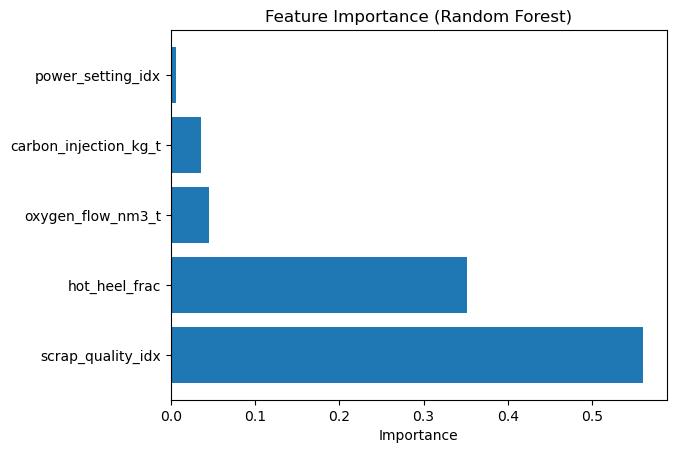

In [50]:
#Feature Importance

importances = rf_model.feature_importances_
features = X.columns

plt.barh(features, importances)
plt.xlabel("Importance")
plt.title("Feature Importance (Random Forest)")
plt.show()

In [51]:
#Best Model for Optimization

model_dict = {
    "Linear Regression": (lr_model, rmse_lr),
    "Random Forest": (rf_model, rmse_rf),
    "XGBoost": (xgb_model, rmse_xgb)
}

# Selecting the model with the lowest RMSE
best_model_name, (best_model, best_rmse) = min(model_dict.items(), key=lambda x: x[1][1])

print("Best model selected for optimization:", best_model_name)
print("Best RMSE:", round(best_rmse, 2))

Best model selected for optimization: XGBoost
Best RMSE: 8.0


In [52]:
#baseline operating condition

baseline_input = {
    "scrap_quality_idx": 0.88,
    "hot_heel_frac": 0.25,
    "oxygen_flow_nm3_t": 30,
    "carbon_injection_kg_t": 10,
    "power_setting_idx": 0.90
}

baseline_df = pd.DataFrame([baseline_input])

baseline_energy = best_model.predict(baseline_df)[0]

print("Baseline predicted energy:", round(baseline_energy, 2), "kWh/t")

Baseline predicted energy: 375.09 kWh/t


In [53]:
#Optimization

def optimize_eaf_energy(model, scrap_quality, hot_heel,
                        oxygen_range, carbon_range, power_range):
    
    best_energy = float("inf")
    best_settings = None
    all_results = []

    for oxygen in oxygen_range:
        for carbon in carbon_range:
            for power in power_range:
                candidate = pd.DataFrame([{
                    "scrap_quality_idx": scrap_quality,
                    "hot_heel_frac": hot_heel,
                    "oxygen_flow_nm3_t": oxygen,
                    "carbon_injection_kg_t": carbon,
                    "power_setting_idx": power
                }])

                pred_energy = model.predict(candidate)[0]

               

                all_results.append({
                    "scrap_quality_idx": scrap_quality,
                    "hot_heel_frac": hot_heel,
                    "oxygen_flow_nm3_t": oxygen,
                    "carbon_injection_kg_t": carbon,
                    "power_setting_idx": power,
                    "predicted_energy_kwh_t": pred_energy,
                    
                })

                if pred_energy < best_energy:
                    best_energy = pred_energy
                    best_settings = candidate.iloc[0].to_dict()

    return best_energy, best_settings, pd.DataFrame(all_results)
   

In [54]:
best_energy, best_settings, results_df = optimize_eaf_energy(
    model=best_model,
    scrap_quality=0.88,
    hot_heel=0.25,
    oxygen_range=np.arange(20, 51, 2),
    carbon_range=np.arange(5, 21, 1),
    power_range=np.arange(0.75, 1.06, 0.01)
)

print("Optimized predicted energy:", round(best_energy, 2), "kWh/t")
print("Best settings:", best_settings)

Optimized predicted energy: 373.52 kWh/t
Best settings: {'scrap_quality_idx': 0.88, 'hot_heel_frac': 0.25, 'oxygen_flow_nm3_t': 32.0, 'carbon_injection_kg_t': 10.0, 'power_setting_idx': 0.8}


In [55]:
#Comparing baseline vs optimized result

improvement_kwh_t = baseline_energy - best_energy
improvement_pct = (improvement_kwh_t / baseline_energy) * 100

print("Baseline energy:", round(baseline_energy, 2), "kWh/t")
print("Optimized energy:", round(best_energy, 2), "kWh/t")
print("Energy reduction:", round(improvement_kwh_t, 2), "kWh/t")
print("Percent improvement:", round(improvement_pct, 2), "%")

Baseline energy: 375.09 kWh/t
Optimized energy: 373.52 kWh/t
Energy reduction: 1.57 kWh/t
Percent improvement: 0.42 %


In [56]:
# Results summary table

summary_df = pd.DataFrame([
    {
        "Case": "Baseline",
        "scrap_quality_idx": baseline_input["scrap_quality_idx"],
        "hot_heel_frac": baseline_input["hot_heel_frac"],
        "oxygen_flow_nm3_t": baseline_input["oxygen_flow_nm3_t"],
        "carbon_injection_kg_t": baseline_input["carbon_injection_kg_t"],
        "power_setting_idx": baseline_input["power_setting_idx"],
        "predicted_energy_kwh_t": baseline_energy
    },
    {
        "Case": "Optimized",
        "scrap_quality_idx": best_settings["scrap_quality_idx"],
        "hot_heel_frac": best_settings["hot_heel_frac"],
        "oxygen_flow_nm3_t": best_settings["oxygen_flow_nm3_t"],
        "carbon_injection_kg_t": best_settings["carbon_injection_kg_t"],
        "power_setting_idx": best_settings["power_setting_idx"],
        "predicted_energy_kwh_t": best_energy
    }
])

print(summary_df)

        Case  scrap_quality_idx  hot_heel_frac  oxygen_flow_nm3_t  \
0   Baseline               0.88           0.25               30.0   
1  Optimized               0.88           0.25               32.0   

   carbon_injection_kg_t  power_setting_idx  predicted_energy_kwh_t  
0                   10.0                0.9              375.089661  
1                   10.0                0.8              373.517609  


In [57]:


# Showing the top 10 best operating conditions
top_10 = results_df.sort_values(by="predicted_energy_kwh_t").head(10)
print(top_10)

      scrap_quality_idx  hot_heel_frac  oxygen_flow_nm3_t  \
3237               0.88           0.25                 32   
3238               0.88           0.25                 32   
3232               0.88           0.25                 32   
3233               0.88           0.25                 32   
3234               0.88           0.25                 32   
3235               0.88           0.25                 32   
3236               0.88           0.25                 32   
3750               0.88           0.25                 34   
3749               0.88           0.25                 34   
3244               0.88           0.25                 32   

      carbon_injection_kg_t  power_setting_idx  predicted_energy_kwh_t  
3237                     10               0.80              373.517609  
3238                     10               0.81              373.517609  
3232                     10               0.75              373.629547  
3233                     10         

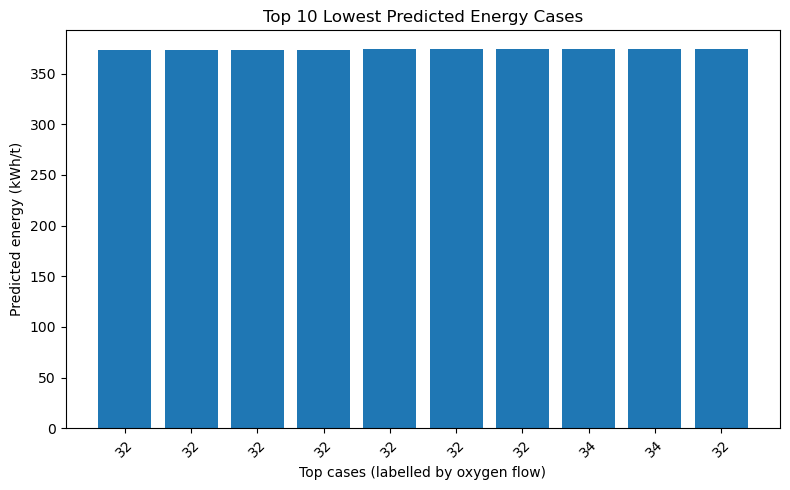

In [58]:

top_10_sorted = top_10.sort_values(by="predicted_energy_kwh_t", ascending=True)

plt.figure(figsize=(8, 5))
plt.bar(range(len(top_10_sorted)), top_10_sorted["predicted_energy_kwh_t"])
plt.xticks(range(len(top_10_sorted)), top_10_sorted["oxygen_flow_nm3_t"].astype(str), rotation=45)
plt.xlabel("Top cases (labelled by oxygen flow)")
plt.ylabel("Predicted energy (kWh/t)")
plt.title("Top 10 Lowest Predicted Energy Cases")
plt.tight_layout()
plt.show()

In [59]:
#Senarios Comparison


scenarios = [
    {
        "name": "Low Scrap Quality",
        "scrap_quality": 0.68,
        "hot_heel": 0.20,
        "oxygen_range": np.arange(20, 51, 2),
        "carbon_range": np.arange(5, 21, 1),
        "power_range": np.arange(0.75, 1.06, 0.01),
        "baseline_oxygen": 30,
        "baseline_carbon": 10,
        "baseline_power": 0.90
    },
    {
        "name": "Medium Scrap Quality",
        "scrap_quality": 0.75,
        "hot_heel": 0.25,
        "oxygen_range": np.arange(20, 51, 2),
        "carbon_range": np.arange(5, 21, 1),
        "power_range": np.arange(0.75, 1.06, 0.01),
        "baseline_oxygen": 30,
        "baseline_carbon": 10,
        "baseline_power": 0.90
    },
    {
        "name": "Restricted Oxygen",
        "scrap_quality": 0.85,
        "hot_heel": 0.25,
        "oxygen_range": np.arange(20, 41, 2),
        "carbon_range": np.arange(5, 21, 1),
        "power_range": np.arange(0.75, 1.06, 0.01),
        "baseline_oxygen": 28,
        "baseline_carbon": 10,
        "baseline_power": 0.90
    }
]

In [60]:
#Senario dataframe

scenario_results = []

for s in scenarios:
    baseline_df = pd.DataFrame([{
        "scrap_quality_idx": s["scrap_quality"],
        "hot_heel_frac": s["hot_heel"],
        "oxygen_flow_nm3_t": s["baseline_oxygen"],
        "carbon_injection_kg_t": s["baseline_carbon"],
        "power_setting_idx": s["baseline_power"]
    }])

    baseline_energy = best_model.predict(baseline_df)[0]

    best_energy, best_settings, results_df = optimize_eaf_energy(
        model=best_model,
        scrap_quality=s["scrap_quality"],
        hot_heel=s["hot_heel"],
        oxygen_range=s["oxygen_range"],
        carbon_range=s["carbon_range"],
        power_range=s["power_range"]
    )

    savings = baseline_energy - best_energy
    savings_pct = (savings / baseline_energy) * 100

    scenario_results.append({
        "Scenario": s["name"],
        "Baseline Energy (kWh/t)": round(baseline_energy, 2),
        "Optimized Energy (kWh/t)": round(best_energy, 2),
        "Savings (kWh/t)": round(savings, 2),
        "Savings (%)": round(savings_pct, 2),
        "Best Oxygen (Nm3/t)": best_settings["oxygen_flow_nm3_t"],
        "Best Carbon (kg/t)": best_settings["carbon_injection_kg_t"],
        "Best Power (kWh/t)": best_settings["power_setting_idx"]
    })

scenario_df = pd.DataFrame(scenario_results)
print(scenario_df)

               Scenario  Baseline Energy (kWh/t)  Optimized Energy (kWh/t)  \
0     Low Scrap Quality               435.720001                430.929993   
1  Medium Scrap Quality               416.859985                414.959991   
2     Restricted Oxygen               385.589996                382.029999   

   Savings (kWh/t)  Savings (%)  Best Oxygen (Nm3/t)  Best Carbon (kg/t)  \
0             4.79         1.10                 32.0                11.0   
1             1.90         0.46                 32.0                10.0   
2             3.55         0.92                 32.0                10.0   

   Best Power (kWh/t)  
0                1.04  
1                0.80  
2                0.80  


KEY FINDINGS


1. XGBoost demonstrated strong predictive performance (RMSE = 7.21, R² = 0.886), indicating its suitability for modeling nonlinear relationships in EAF    operations.
2. The optimization identified balanced operating conditions rather than extreme values, with carbon injection, oxygen flow , and power levels.
3. The results show that minimizing energy consumption requires a trade-off between process efficiency and resource usage, rather than simply              increasing all inputs.
4. Oxygen and carbon exhibit optimal operating ranges, beyond which additional input does not significantly improve energy efficiency.
5. The model highlights that effective EAF operation is achieved through coordinated adjustment of multiple variables, rather than independent tuning      of individual parameters.
6. Scenario based evaluation confirms that optimal settings vary with furnace conditions, emphasizing the importance of adaptive and condition specific    optimization strategies.

LIMITATIONS

1. The dataset remains synthetic, based on assumed process relationships rather than real industrial measurements.
2. The penalty weights were manually selected, which introduces subjectivity and may influence optimization outcomes.
3. The model is static and does not capture time-dependent furnace behavior (e.g., melting stages, arc dynamics).
4. Key industrial factors such as cost of electricity, carbon consumption, emissions, and refractory wear are not explicitly modeled.
5. The “power” variable represents an operating intensity proxy rather than actual grid power (MW), which simplifies real process behavior.

FUTURE IMPROVEMENTS

1. Integrate real plant data to improve model validation and reliability.
2. Develop a data-driven method for tuning penalty weights, or extend to multi-objective optimization.
3. Incorporate economic and environmental objectives (cost, CO₂ emissions, material consumption).
4. Extend the model to include dynamic process behavior (time-dependent modeling of EAF operation).
5. Replace the simplified power representation with a more physical model separating power and process duration.
6. Deploy the model as a real-time decision-support tool for adaptive furnace optimization.